Projet PEA-PETTAL : Suivi Agronomique et Phytosanitaire du Sorgho

Base de Données des Producteurs - Commune de Mbadakhoune (Kaolack)

In [55]:
import pandas as pd
import numpy as np

Configuration pour la reproductibilité

In [28]:
np.random.seed(42)
n_producteurs = 500
print("Génération des données agronomiques pour Mbadakhoune (Kaolack)...")

Génération des données agronomiques pour Mbadakhoune (Kaolack)...


1. Variables de base

In [29]:
ids = [f"SORGH-2026-{i:03d}" for i in range(1, n_producteurs + 1)]
villages = np.random.choice(["Mbadakhoune Centre", "Keur DIATTA", "Ndiédieng", "Thioffior", "Gandiaye-Secteur"], n_producteurs)
superficie = np.round(np.random.uniform(1.0, 5.5, n_producteurs), 2)  # en hectares
varietes = np.random.choice(["Fadda (Hybride)", "Darou (Améliorée)", "Locale"], n_producteurs, p=[0.4, 0.4, 0.2])

2. Facteurs environnementaux et intrants

In [30]:
pluviometrie = np.round(np.random.normal(700, 60, n_producteurs), 1)  # en mm (climat Kaolack)
engrais_npk = np.round(np.random.uniform(50, 150, n_producteurs), 1)  # kg/ha
taux_germination = np.random.randint(65, 98, n_producteurs)  # en %

3. Volet Phytosanitaire (Ravageurs)

In [31]:
attaques_ravageurs = np.random.choice(["Aucune", "Striga", "Chenille Légionnaire"], n_producteurs, p=[0.6, 0.25, 0.15])
indice_ndvi = np.round(np.random.uniform(0.35, 0.78, n_producteurs), 2)  # Vigueur végétative

Adjustement de l'indice NDVI selon les attaques

In [32]:
for i in range(n_producteurs):
    if attaques_ravageurs[i] == "Striga":
        indice_ndvi[i] -= np.round(np.random.uniform(0.1, 0.2), 2)
    elif attaques_ravageurs[i] == "Chenille Légionnaire":
        indice_ndvi[i] -= np.round(np.random.uniform(0.15, 0.25), 2)
indice_ndvi = np.clip(indice_ndvi, 0.1, 0.9) # Sécurité pour rester dans les normes

4. Modélisation complexe du Rendement (Kg/Ha) - Équation pour le Machine Learning
Le rendement dépend de la variété, de la pluie, de l'engrais et est pénalisé par les ravageurs

In [33]:
rendement_base = 800
rendement = (rendement_base + 
             (engrais_npk * 2.5) + 
             ((pluviometrie - 600) * 1.2) + 
             (taux_germination * 3))

Effet variété

In [34]:
rendement = np.where(varietes == "Fadda (Hybride)", rendement * 1.35, rendement)
rendement = np.where(varietes == "Darou (Améliorée)", rendement * 1.15, rendement)

Impact phytosanitaire

In [35]:
rendement = np.where(attaques_ravageurs == "Striga", rendement * 0.70, rendement)
rendement = np.where(attaques_ravageurs == "Chenille Légionnaire", rendement * 0.55, rendement)

Ajout d'un bruit réaliste (variations aléatoires du terrain)

In [36]:
rendement += np.random.normal(0, 75, n_producteurs)
rendement = np.round(np.clip(rendement, 400, 2500), 0) # Rendements réalistes pour le Sorgho

5. Création du DataFrame Pandas

In [37]:
df_sorgho = pd.DataFrame({
    "id_producteur": ids,
    "village": villages,
    "superficie_ha": superficie,
    "variete": varietes,
    "pluviometrie_mm": pluviometrie,
    "engrais_npk_kg_ha": engrais_npk,
    "taux_germination_pct": taux_germination,
    "pression_phytosanitaire": attaques_ravageurs,
    "indice_ndvi": indice_ndvi,
    "rendement_kg_ha": rendement})

Sauvegarde au format CSV

In [38]:
output_file = "producteurs_sorgho_mbadakhoune.csv"
df_sorgho.to_csv(output_file, index=False, encoding="utf-8")
print(f"Terminé ! Le fichier '{output_file}' contenant {n_producteurs} lignes a été créé avec succès.")

Terminé ! Le fichier 'producteurs_sorgho_mbadakhoune.csv' contenant 500 lignes a été créé avec succès.


Affichage des 5 premières lignes

In [39]:
df_sorgho.head()

,id_producteur,village,superficie_ha,variete,pluviometrie_mm,engrais_npk_kg_ha,taux_germination_pct,pression_phytosanitaire,indice_ndvi,rendement_kg_ha
0,SORGH-2026-001,Thioffior,3.27,Fadda (Hybride),680.7,102.3,66,Striga,0.25,1323.0
1,SORGH-2026-002,Gandiaye-Secteur,4.72,Darou (Améliorée),824.6,61.5,87,Striga,0.25,1209.0
2,SORGH-2026-003,Ndiédieng,2.44,Darou (Améliorée),722.9,136.0,73,Aucune,0.35,1643.0
3,SORGH-2026-004,Gandiaye-Secteur,5.03,Locale,725.8,122.3,78,Striga,0.31,1125.0
4,SORGH-2026-005,Gandiaye-Secteur,2.75,Locale,761.8,56.8,68,Striga,0.34,999.0


1. Analyse Univariée Complète

Sélection des variables numériques d'après ton jeu de données

In [40]:
colonnes_num = ['superficie_ha', 'pluviometrie_mm', 'engrais_npk_kg_ha', 'taux_germination_pct', 'indice_ndvi', 'rendement_kg_ha']
print("")

1.1. Calcul des statistiques descriptives fondamentales

In [41]:
univariet_num = df_sorgho[colonnes_num].describe(percentiles=[0.25, 0.5, 0.75]).T

1.2. Ajout des indicateurs spécifiques

In [42]:
univariet_num['étendue'] = univariet_num['max'] - univariet_num['min']
univariet_num['médiane'] = df_sorgho[colonnes_num].median()
univariet_num['variance'] = df_sorgho[colonnes_num].var()
univariet_num['mode'] = df_sorgho[colonnes_num].mode().iloc[0]

 Réorganisation pour l'affichage

In [43]:
univariet_num = univariet_num[['count', 'mean', 'étendue', 'min', '25%', 'médiane', '75%', 'max', 'mode', 'std', 'variance']]
univariet_num.columns = ['Effectif', 'Moyenne', 'Étendue', 'Minimum', 'Quartile 1 (25%)', 'Médiane (50%)', 'Quartile 3 (75%)', 'Maximum', 'Mode', 'Écart-type', 'Variance']

print("TABLEAU DES STATISTIQUES UNIVARIÉES NUMÉRIQUES")
display(univariet_num.round(3))

print("\n")
print("FRÉQUENCES DES VARIABLES QUALITATIVES (TRIS À PLAT)")
for col in ['village', 'variete', 'pression_phytosanitaire']:
    freq = df_sorgho[col].value_counts().to_frame()
    freq.columns = ['Effectif']
    freq['Pourcentage (%)'] = (df_sorgho[col].value_counts(normalize=True) * 100).round(2)
    print(f"\nVariable : {col.upper()}")
    display(freq)

TABLEAU DES STATISTIQUES UNIVARIÉES NUMÉRIQUES


,Effectif,Moyenne,Étendue,Minimum,Quartile 1 (25%),Médiane (50%),Quartile 3 (75%),Maximum,Mode,Écart-type,Variance
superficie_ha,500.0,3.202,4.48,1.02,2.007,3.175,4.360,5.50,1.38,1.322,1.748
pluviometrie_mm,500.0,704.461,329.90,526.20,661.625,703.400,744.025,856.10,633.80,60.966,3716.819
engrais_npk_kg_ha,500.0,100.818,99.60,50.20,77.900,101.250,125.625,149.80,95.90,28.650,820.851
taux_germination_pct,500.0,81.086,32.00,65.00,73.000,81.000,89.000,97.00,81.00,9.377,87.922
indice_ndvi,500.0,0.487,0.66,0.12,0.370,0.485,0.600,0.78,0.59,0.155,0.024
rendement_kg_ha,500.0,1441.780,1676.00,586.00,1151.000,1454.000,1747.750,2262.00,784.00,378.227,143055.759




FRÉQUENCES DES VARIABLES QUALITATIVES (TRIS À PLAT)

Variable : VILLAGE


,Effectif,Pourcentage (%)
village,,
Thioffior,112,22.4
Mbadakhoune Centre,109,21.8
Keur DIATTA,95,19.0
Gandiaye-Secteur,93,18.6
Ndiédieng,91,18.2



Variable : VARIETE


,Effectif,Pourcentage (%)
variete,,
Darou (Améliorée),199,39.8
Fadda (Hybride),195,39.0
Locale,106,21.2



Variable : PRESSION_PHYTOSANITAIRE


,Effectif,Pourcentage (%)
pression_phytosanitaire,,
Aucune,287,57.4
Striga,139,27.8
Chenille Légionnaire,74,14.8


2. Analyse Bivariée

In [44]:
print("")
print("1. MATRICE DE CORRÉLATION (BIVARIÉE NUMÉRIQUE)")
matrice_corr = df_sorgho[colonnes_num].corr()
display(matrice_corr.round(3))

print("\n")
print("2. TABLEAU CROISÉ : VARIÉTÉS vs RAVAGEURS")
tableau_croise = pd.crosstab(df_sorgho['variete'], df_sorgho['pression_phytosanitaire'], margins=True, margins_name="Total Général")
display(tableau_croise)

print("\n En pourcentages par ligne (Profils-Lignes) :")
tableau_croise_pct = pd.crosstab(df_sorgho['variete'], df_sorgho['pression_phytosanitaire'], normalize='index').round(4) * 100
display(tableau_croise_pct)


1. MATRICE DE CORRÉLATION (BIVARIÉE NUMÉRIQUE)


,superficie_ha,pluviometrie_mm,engrais_npk_kg_ha,taux_germination_pct,indice_ndvi,rendement_kg_ha
superficie_ha,1.000,-0.007,-0.031,-0.068,0.041,0.014
pluviometrie_mm,-0.007,1.000,0.046,-0.009,0.122,0.307
engrais_npk_kg_ha,-0.031,0.046,1.000,-0.043,0.022,0.289
taux_germination_pct,-0.068,-0.009,-0.043,1.000,-0.035,0.036
indice_ndvi,0.041,0.122,0.022,-0.035,1.000,0.480
rendement_kg_ha,0.014,0.307,0.289,0.036,0.480,1.000




2. TABLEAU CROISÉ : VARIÉTÉS vs RAVAGEURS


pression_phytosanitaire,Aucune,Chenille Légionnaire,Striga,Total Général
variete,,,,
Darou (Améliorée),115,30,54,199
Fadda (Hybride),106,28,61,195
Locale,66,16,24,106
Total Général,287,74,139,500



 En pourcentages par ligne (Profils-Lignes) :


pression_phytosanitaire,Aucune,Chenille Légionnaire,Striga
variete,,,
Darou (Améliorée),57.79,15.08,27.14
Fadda (Hybride),54.36,14.36,31.28
Locale,62.26,15.09,22.64


3 Génération des Graphiques Agro-Statistiques

In [45]:
!pip install seaborn

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns


1. Configuration globale du style graphique

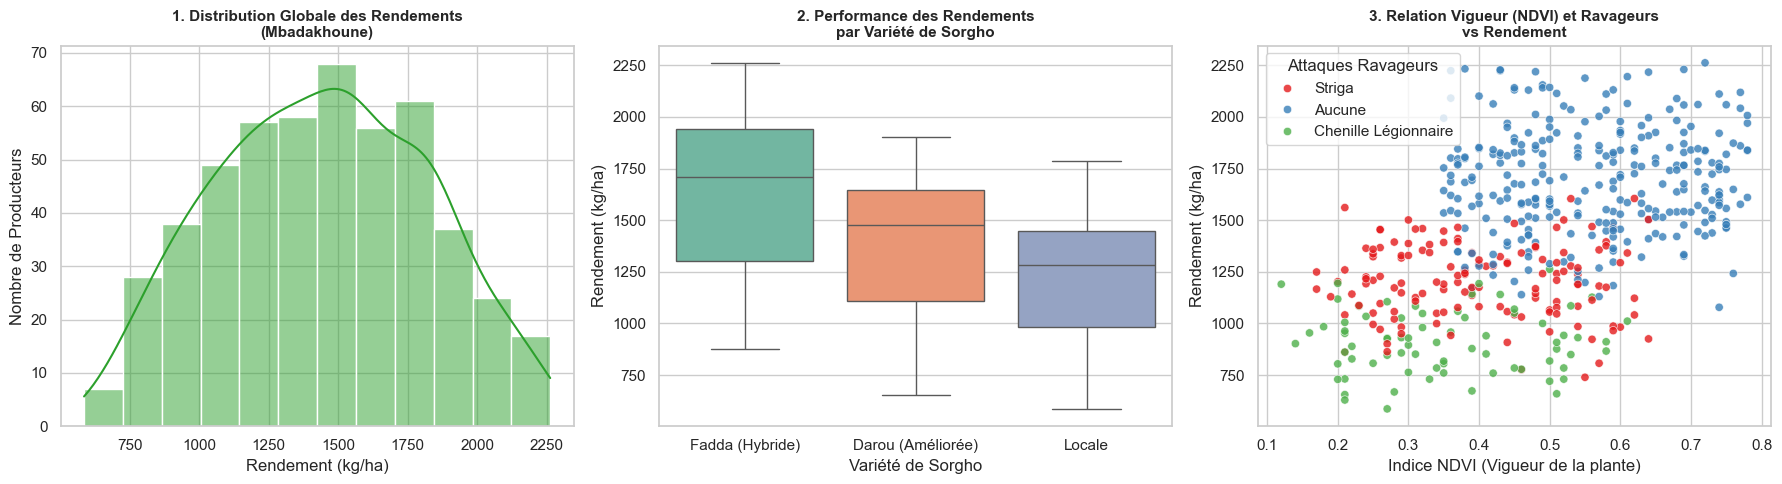

In [56]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRAPHIQUE 1 : Histogramme du Rendement ---
sns.histplot(df_sorgho['rendement_kg_ha'], kde=True, color='#2ca02c', ax=axes[0])
axes[0].set_title("1. Distribution Globale des Rendements\n(Mbadakhoune)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Rendement (kg/ha)")
axes[0].set_ylabel("Nombre de Producteurs")

# --- GRAPHIQUE 2 : Boxplot Variété vs Rendement (Corrigé pour éviter le warning rose) ---
sns.boxplot(x='variete', y='rendement_kg_ha', hue='variete', data=df_sorgho, palette='Set2', legend=False, ax=axes[1])
axes[1].set_title("2. Performance des Rendements\npar Variété de Sorgho", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Variété de Sorgho")
axes[1].set_ylabel("Rendement (kg/ha)")

# --- GRAPHIQUE 3 : Scatterplot NDVI vs Rendement ---
sns.scatterplot(x='indice_ndvi', y='rendement_kg_ha', hue='pression_phytosanitaire', data=df_sorgho, palette='Set1', alpha=0.8, ax=axes[2])
axes[2].set_title("3. Relation Vigueur (NDVI) et Ravageurs\nvs Rendement", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Indice NDVI (Vigueur de la plante)")
axes[2].set_ylabel("Rendement (kg/ha)")
axes[2].legend(title="Attaques Ravageurs")

plt.tight_layout()
plt.show()


Les Tests Statistiques

1 : Indicateurs de base et Forme (Variance, Skewness...)

In [48]:
import scipy.stats as stats

# On prépare les groupes une fois pour toutes
rendement_fadda = df_sorgho[df_sorgho['variete'] == 'Fadda (Hybride)']['rendement_kg_ha']
rendement_darou = df_sorgho[df_sorgho['variete'] == 'Darou (Améliorée)']['rendement_kg_ha']
rendement_locale = df_sorgho[df_sorgho['variete'] == 'Locale']['rendement_kg_ha']

print("")
print("1. VÉRIFICATION DES INDICATEURS DE BASE (RENDEMENT)")
print(f"Écart-type : {df_sorgho['rendement_kg_ha'].std():.2f} kg/ha")
print(f"Variance   : {df_sorgho['rendement_kg_ha'].var():.2f}")
print(f"Skewness   : {df_sorgho['rendement_kg_ha'].skew():.3f} (Asymétrie)")
print(f"Kurtosis   : {df_sorgho['rendement_kg_ha'].kurt():.3f} (Aplatissement)")


1. VÉRIFICATION DES INDICATEURS DE BASE (RENDEMENT)
Écart-type : 378.23 kg/ha
Variance   : 143055.76
Skewness   : 0.007 (Asymétrie)
Kurtosis   : -0.769 (Aplatissement)


2 : Tests de Normalité (Shapiro & Kolmogorov)

In [49]:
print("")
print("2. TESTS DE NORMALITÉ (SUR LE RENDEMENT)")

# Test de Shapiro-Wilk
_, p_shapiro = stats.shapiro(df_sorgho['rendement_kg_ha'])
print(f"Shapiro-Wilk p-value       : {p_shapiro:.3e}")

# Test de Kolmogorov-Smirnov
rendement_cr = (df_sorgho['rendement_kg_ha'] - df_sorgho['rendement_kg_ha'].mean()) / df_sorgho['rendement_kg_ha'].std()
_, p_ks = stats.kstest(rendement_cr, 'norm')
print(f"Kolmogorov-Smirnov p-value : {p_ks:.3f}")


2. TESTS DE NORMALITÉ (SUR LE RENDEMENT)
Shapiro-Wilk p-value       : 1.508e-04
Kolmogorov-Smirnov p-value : 0.224


3 : Tests de Corrélation et Dépendance (Pearson & Chi-Deux)

In [50]:
import pandas as pd

print("")
print("3. TESTS DE CORRÉLATION ET DE DÉPENDANCE")

# Test de Corrélation de Pearson (NDVI vs Rendement)
r_coeff, p_pearson = stats.pearsonr(df_sorgho['indice_ndvi'], df_sorgho['rendement_kg_ha'])
print(f"Pearson (r) [NDVI vs Rendement]         : {r_coeff:.3f} (p-value: {p_pearson:.3e})")

# Test du Chi-deux (Variétés vs Ravageurs)
table_contingence = pd.crosstab(df_sorgho['variete'], df_sorgho['pression_phytosanitaire'])
_, p_chi2, _, _ = stats.chi2_contingency(table_contingence)
print(f"Chi-deux (X²) [Variétés vs Ravageurs]    : p-value = {p_chi2:.3f}")


3. TESTS DE CORRÉLATION ET DE DÉPENDANCE
Pearson (r) [NDVI vs Rendement]         : 0.480 (p-value: 4.006e-30)
Chi-deux (X²) [Variétés vs Ravageurs]    : p-value = 0.610


4 : Tests de Comparaison (Bartlett, ANOVA & Student)

In [51]:
print("")
print("4. TESTS DE COMPARAISON DES GROUPES DE VARIÉTÉS")

# Test de Bartlett
_, p_bartlett = stats.bartlett(rendement_fadda, rendement_darou, rendement_locale)
print(f"Bartlett (Homogénéité des variances)     : p-value = {p_bartlett:.3f}")

# Test d'ANOVA
_, p_anova = stats.f_oneway(rendement_fadda, rendement_darou, rendement_locale)
print(f"ANOVA (Comparaison des 3 variétés)       : p-value = {p_anova:.3e}")

# Test de Student
_, p_student = stats.ttest_ind(rendement_fadda, rendement_locale, equal_var=True)
print(f"Test de Student (Fadda vs Locale)        : p-value = {p_student:.3e}")


4. TESTS DE COMPARAISON DES GROUPES DE VARIÉTÉS
Bartlett (Homogénéité des variances)     : p-value = 0.010
ANOVA (Comparaison des 3 variétés)       : p-value = 2.981e-21
Test de Student (Fadda vs Locale)        : p-value = 1.032e-18


Analyse en Composantes Principales (ACP)

In [53]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------------------------

--- VARIANCE EXPLIQUÉE PAR LES AXES DE L'ACP ---
Axe 1 (PC1) : 28.44% de l'information globale
Axe 2 (PC2) : 17.94% de l'information globale
Information totale cumulée : 46.38%



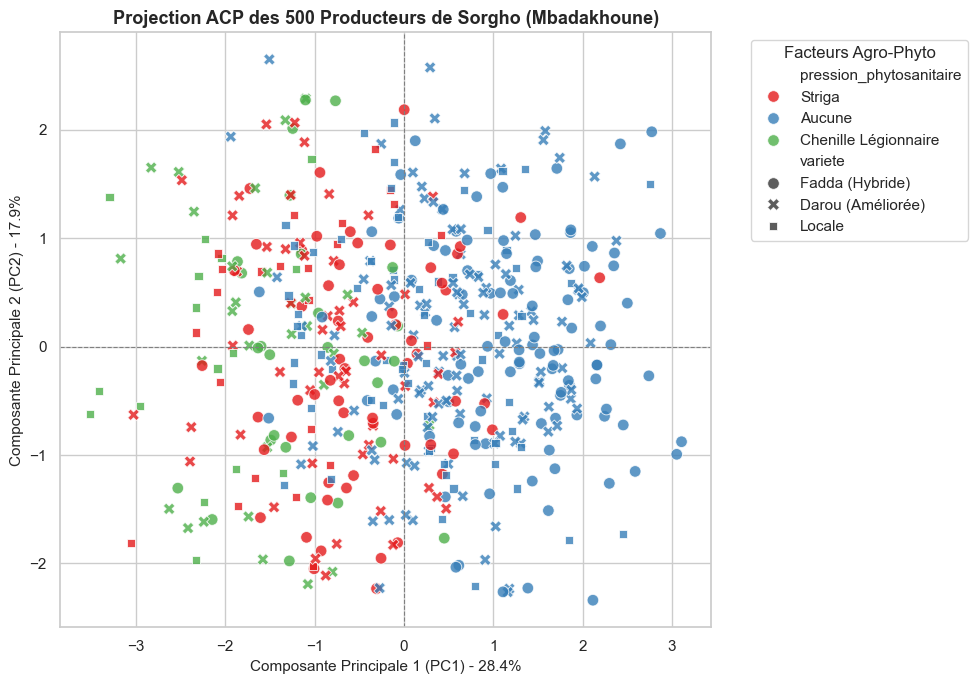

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Sélection des variables numériques d'après ton jeu de données
variables_numeriques = ['superficie_ha', 'pluviometrie_mm', 'engrais_npk_kg_ha', 'taux_germination_pct', 'indice_ndvi', 'rendement_kg_ha']
X = df_sorgho[variables_numeriques]

# 2. Centrage-réduction (Standardisation indispensable pour l'ACP)
X_scaled = StandardScaler().fit_transform(X)

# 3. Application de l'ACP sur les 2 premiers axes principaux
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Création du DataFrame de projection
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['variete'] = df_sorgho['variete']
df_pca['pression_phytosanitaire'] = df_sorgho['pression_phytosanitaire']

# 5. Affichage du pourcentage d'information captée (Variance expliquée)
variance_expliquee = pca.explained_variance_ratio_ * 100
print("--- VARIANCE EXPLIQUÉE PAR LES AXES DE L'ACP ---")
print(f"Axe 1 (PC1) : {variance_expliquee[0]:.2f}% de l'information globale")
print(f"Axe 2 (PC2) : {variance_expliquee[1]:.2f}% de l'information globale")
print(f"Information totale cumulée : {sum(variance_expliquee):.2f}%\n")

# 6. Génération du graphique de projection des producteurs (Biplot)
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='pression_phytosanitaire',
    style='variete',
    data=df_pca,
    palette='Set1',
    alpha=0.8,
    s=70,
)

plt.title(
    "Projection ACP des 500 Producteurs de Sorgho (Mbadakhoune)",
    fontsize=13,
    fontweight='bold',
)
plt.xlabel(f"Composante Principale 1 (PC1) - {variance_expliquee[0]:.1f}%", fontsize=11)
plt.ylabel(f"Composante Principale 2 (PC2) - {variance_expliquee[1]:.1f}%", fontsize=11)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Facteurs Agro-Phyto")
plt.tight_layout()
plt.show()

In [57]:
plt.savefig('acp_producteurs_sorgho.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [59]:
%pwd

'C:\\Users\\DELL'